# First Task: (20 points) Load the MPC data, and pre-process the data.
- lower-case text
- expand contractions
- split the documents into tokens
- remove non-ascii characters, remove short tokens, remove punctuation and
numbers, remove stopwords
- stemming and lemmatization

### 1.1 Import Packages and Build Stopword Set

**Operation:**
- 导入文本预处理所需的所有库（NLTK、scikit-learn、tqdm 等）
- 构建扩展停用词表：
  起初只使用了NLTK 英文停用词 + scikit-learn 停用词，之后在完成topic的分类后发现有一些无意义的词语未被停用，最后加上了一些自定义无意义词（would, could, might, also 等），使用 `set` 的并集操作合并三个停用词来源，确保覆盖更多无意义词。

In [1]:
# Imports and expanded stopword set
from pathlib import Path
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tqdm.auto import tqdm

# Ensure required resources
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

base_stop = set(stopwords.words("english"))
sk_stop = set(ENGLISH_STOP_WORDS)
extra_stop = {
    "would", "could", "should", "might", "also", "may", "even", "yet",
    "one", "two", "three", "four", "five",
    "say", "says", "said",
    "mr", "mrs", "ms",
    "like", "just", "get", "got", "make", "made",
    "many", "much", "still",
    "thing", "things", "going", "year", "years"
}
stop_words = base_stop | sk_stop | extra_stop

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

### 1.2 Load Raw Data

**Operation:**
- 读取 MPC（货币政策委员会）会议纪要文本
- 按行分割文本，每行作为一个独立的文档

In [2]:
# Load raw MPC minutes
data_path = Path("../raw/mpc_minutes.txt")
raw_text = data_path.read_text(encoding="utf-8", errors="ignore")
documents = [line.strip() for line in raw_text.splitlines() if line.strip()]
print(f"Loaded {len(documents)} documents from {data_path}")

Loaded 7278 documents from ../raw/mpc_minutes.txt


### 1.3 Contraction Expansion Helper

**Operation:**

- 使用 `contractions` 库将英文缩写形式展开为完整形式（如 "don't" → "do not"），便于后续分词和停用词匹配

In [3]:
# Contraction expansion helper
try:
    import contractions
    def expand_contractions(text: str) -> str:
        return contractions.fix(text)
except ImportError:
    CONTRACTION_MAP = {
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'ve": " have",
        "'m": " am"
    }
    contraction_pattern = re.compile("|".join(map(re.escape, CONTRACTION_MAP.keys())))
    def expand_contractions(text: str) -> str:
        return contraction_pattern.sub(lambda m: CONTRACTION_MAP[m.group(0)], text)

### 1.4 定义文本预处理流水线 / Define Text Preprocessing Pipeline

**Operation:**
首先对所有的单词进行小写化和缩写展开，然后使用NLTK的`word_tokenize` 进行分词，然后进行过滤（非ASCII、短词、非字母、停用词），最后使用`PorterStemmer` 进行词干提取，使用`WordNetLemmatizer` 进行词形还原。

In [4]:
# Tokenization and normalization pipeline
def preprocess_document(text: str) -> dict:
    text = text.lower()
    text = expand_contractions(text)
    tokens = word_tokenize(text)
    cleaned = []
    for tok in tokens:
        tok_ascii = tok.encode("ascii", "ignore").decode("ascii")
        if not tok_ascii:
            continue
        if len(tok_ascii) < 3:
            continue
        if not tok_ascii.isalpha():
            continue
        if tok_ascii in stop_words:
            continue
        cleaned.append(tok_ascii)
    stemmed = [stemmer.stem(t) for t in cleaned]
    lemmatized = [lemmatizer.lemmatize(t) for t in cleaned]
    return {
        "tokens": cleaned,
        "stemmed": stemmed,
        "lemmatized": lemmatized
    }

### 1.5 应用预处理并检查样本 / Apply Preprocessing and Inspect Sample

**目的 / Purpose:**
- 对所有文档批量执行预处理，并检查第一个文档的处理结果以验证流水线正确性
- Apply preprocessing to all documents in batch, inspect first document to verify pipeline correctness

**做法 / Method:**
- 使用列表推导式遍历所有文档，`tqdm` 显示进度条
- Use list comprehension with `tqdm` progress bar

**结果 / Result:**
- `processed_docs` 列表包含所有预处理后的文档
- 打印第一个文档的前 30 个 tokens/stems/lemmas 以供检查
- `processed_docs` contains all preprocessed documents
- Print first 30 tokens/stems/lemmas of first document for inspection

In [5]:
# Apply preprocessing and inspect a sample
processed_docs = [preprocess_document(doc) for doc in tqdm(documents, desc="Preprocessing docs")]
print(f"Preprocessed {len(processed_docs)} documents")

if processed_docs:
    sample = processed_docs[0]
    print("Tokens (first doc, first 30):", sample["tokens"][:30])
    print("Stemmed (first 30):", sample["stemmed"][:30])
    print("Lemmas (first 30):", sample["lemmatized"][:30])

Preprocessing docs:   0%|          | 0/7278 [00:00<?, ?it/s]

Preprocessed 7278 documents
Tokens (first doc, first 30): ['minutes']
Stemmed (first 30): ['minut']
Lemmas (first 30): ['minute']


---

# Second Task: (15 points) Count and the frequency.
- generate document frequency (df) ranking for stems
- show the top 10 stems
- plot the df ranking

### 2.1 Compute Document Frequency and Ranking

**Operation:**
- 对每个文档取词干的集合（去重），然后用 `Counter` 统计每个词干的出现文档数
- 绘制前 30 个高频词干的柱状图
- 统计出每个词干在多少个文档中出现（Document Frequency, DF），识别语料库中最常见的词汇

Top 10 stems by document frequency:
growth: 3431
rate: 3342
inflat: 3062
committe: 2982
price: 2830
month: 2783
market: 2754
increas: 2529
expect: 2464
remain: 2159


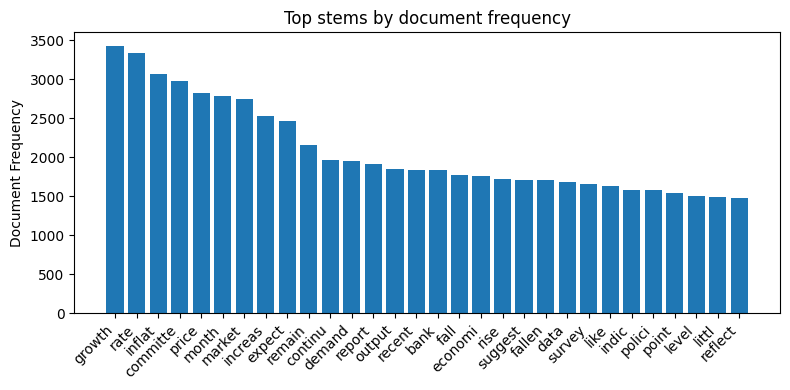

In [6]:
# Document frequency for stems
from collections import Counter
import matplotlib.pyplot as plt

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

unique_stems_per_doc = [set(doc["stemmed"]) for doc in processed_docs]
df_counter = Counter()
for stems in unique_stems_per_doc:
    df_counter.update(stems)

top10 = df_counter.most_common(10)
print("Top 10 stems by document frequency:")
for stem, df in top10:
    print(f"{stem}: {df}")

stems, dfs = zip(*df_counter.most_common(30)) if df_counter else ([], [])
plt.figure(figsize=(8, 4))
plt.bar(range(len(stems)), dfs)
plt.xticks(range(len(stems)), stems, rotation=45, ha="right")
plt.ylabel("Document Frequency")
plt.title("Top stems by document frequency")
plt.tight_layout()
plt.show()

---

# Third Task: Term frequency inverse document frequency (TF-IDF).
- generate TF-IDF ranking of stems
- show the top 10 stems
- plot TF-IDF ranking
- remove stems with a TF-IDF score <= 3,500
- apply the removal and create a new document-term matrix, show the matrix
(num_documents x num_terms)

### 3.1 Compute TF-IDF and Filter Low-Score Terms

**Operation:**
- 使用 `TfidfVectorizer` 构建 TF-IDF 矩阵，按列求和得到每个词的总 TF-IDF 分数，使用 TF-IDF（词频-逆文档频率）衡量每个词对文档的重要性。设置阈值（3500）进行过滤，过滤掉 TF-IDF 累计得分低于阈值的词，保留信息量高的词。

- 最终输出前 10 个高 TF-IDF 词干及其分数，显示过滤后的文档-词矩阵维度 (docs × filtered_terms)。

Top 10 stems by TF-IDF (sum over documents):
growth: 19590.94
rate: 19354.89
price: 16768.19
inflat: 16568.38
fallen: 13890.34
increas: 12998.81
risen: 12367.58
month: 12229.45
market: 10900.84
expect: 10399.43


/opt/anaconda3/envs/5020_env/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


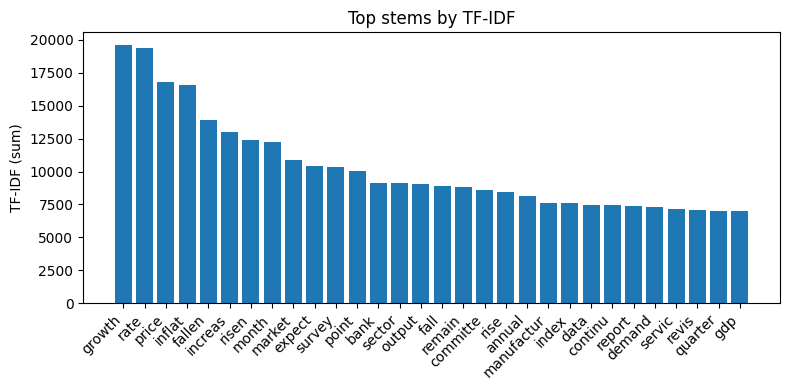

Filtered matrix shape: (7278, 136) (docs x terms) with threshold > 3500
Document-term matrix (first 5 rows):


,account,activ,annual,april,area,asset,august,averag,balanc,bank,...,survey,target,term,time,total,trade,unchang,unemploy,unit,weak
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,4.748283,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,3.712732,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,11.138196,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,11.138196,0.0,0.0,0.0,0.0,0.0,2.374142,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# TF-IDF on stems
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

corpus = [" ".join(doc["stemmed"]) for doc in processed_docs]
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x, lowercase=False, norm=None)
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()
tfidf_sum = tfidf_matrix.sum(axis=0).A1

ranking = sorted(zip(terms, tfidf_sum), key=lambda x: x[1], reverse=True)
top10 = ranking[:10]
print("Top 10 stems by TF-IDF (sum over documents):")
for term, score in top10:
    print(f"{term}: {score:.2f}")

top_terms, top_scores = zip(*ranking[:30]) if ranking else ([], [])
plt.figure(figsize=(8, 4))
plt.bar(range(len(top_terms)), top_scores)
plt.xticks(range(len(top_terms)), top_terms, rotation=45, ha="right")
plt.ylabel("TF-IDF (sum)")
plt.title("Top stems by TF-IDF")
plt.tight_layout()
plt.show()

threshold = 3500
mask = tfidf_sum > threshold
filtered_terms = terms[mask]
filtered_matrix = tfidf_matrix[:, mask]
print(f"Filtered matrix shape: {filtered_matrix.shape} (docs x terms) with threshold > {threshold}")

if filtered_matrix.shape[1] == 0:
    print("No terms exceed the TF-IDF threshold; consider lowering it.")
else:
    dtm = pd.DataFrame(filtered_matrix.toarray(), columns=filtered_terms)
    print("Document-term matrix (first 5 rows):")
    display(dtm.head())

---

# Fourth Task: (40 points) LDA topic model.
- create a LDA object with 30 topics (set the hyperparameter of the Dirichlet prior on topics to 200/number of unique vocabulary elements, set the hyperparameter of the Dirichlet prior on document-topic distributions to 50/number of topics, set the number of sampling iterations be 5000, set the random_state to make sure re-productivity)
- estimate the model (may take 5-10 minutes)
- show the distribution of topics over documents and probability distribution over the vocabulary
- show the top 15 words with highest probability per topic
- create a figure for the first 15 topics
- choose three topics and interpret them (try to summarize the likely topics)

LDA topic model (30 topics).

### 4.1 Train LDA Topic Model

**Operation:**
- 使用 LDA（Latent Dirichlet Allocation，潜在狄利克雷分配）发现文档集合中的潜在主题：

    - 使用 `CountVectorizer` 构建词频矩阵（Bag of Words）
    - 设置 Dirichlet 先验超参数：`doc_topic_prior = 50/n_topics`，`topic_word_prior = 200/vocab_size`
    - 迭代 5000 次（`max_iter=5000`），使用批量学习方法
  
**Result:**
- `doc_topic`: 文档-主题分布矩阵 (docs × topics)
- `topic_word`: 主题-词分布矩阵 (topics × vocab)

In [20]:
# Fit LDA with Dirichlet priors
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

corpus = [" ".join(doc["stemmed"]) for doc in processed_docs]
vectorizer_lda = CountVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x, lowercase=False, vocabulary=filtered_terms)
dtm_counts = vectorizer_lda.fit_transform(corpus)
vocab = vectorizer_lda.get_feature_names_out()
if dtm_counts.shape[1] == 0:
    raise ValueError("Vocabulary is empty after preprocessing; check earlier steps.")

n_topics = 30
alpha_raw = 50 / n_topics
doc_prior = min(alpha_raw, 1.0)  # sklearn requires doc_topic_prior in [0,1]
eta = min(200 / len(vocab), 1.0) if len(vocab) > 0 else 1.0

lda = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=doc_prior,
    topic_word_prior=eta,
    max_iter=5000,
    learning_method="batch",
    random_state=0,
    evaluate_every=-1,
    verbose=0
)
lda.fit(dtm_counts)

doc_topic = lda.transform(dtm_counts)
topic_word = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
print(f"Doc-topic matrix shape: {doc_topic.shape} (docs x topics)")
print(f"Topic-word matrix shape: {topic_word.shape} (topics x vocab)")

/opt/anaconda3/envs/5020_env/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Doc-topic matrix shape: (7278, 30) (docs x topics)
Topic-word matrix shape: (30, 136) (topics x vocab)


### 4.2 Display Top Words per Topic

- 对每个主题的词分布按概率降序排序，取前 15 个词,用来帮助理解和解释主题含义，并且用来人工检查主题分类是否有效。
- 打印每个主题的代表性词汇及其概率
- 展示文档如何在各主题上分布，便于后续主题解释

In [22]:
n_topics = 30
alpha_raw = 50 / n_topics
doc_prior = min(alpha_raw, 1.0) 
eta = 200 / len(vocab) if len(vocab) > 0 else 1.0

lda = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=doc_prior, 
    topic_word_prior=eta,
    max_iter=5000,
    learning_method="batch",
    random_state=0,
    evaluate_every=-1,
    verbose=0
)

In [23]:
n_topics = 30
alpha_raw = 50 / n_topics
doc_prior = min(alpha_raw, 1.0)
eta = 200 / len(vocab) if len(vocab) > 0 else 1.0

lda = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=doc_prior,
    topic_word_prior=eta,
    max_iter=5000,
    learning_method="batch",
    random_state=0,
    evaluate_every=-1,
    verbose=0
)

In [24]:
# Inspect top words per topic and topic weights per doc
import pandas as pd
import numpy as np

def top_words_per_topic(topic_word_matrix, vocab_list, topn=15):
    result = []
    for k, weights in enumerate(topic_word_matrix):
        top_idx = np.argsort(weights)[::-1][:topn]
        result.append((k, [(vocab_list[i], weights[i]) for i in top_idx]))
    return result

top_words = top_words_per_topic(topic_word, vocab, topn=15)
for k, words in top_words:
    words_str = ", ".join([f"{w} ({p:.4f})" for w, p in words])
    print(f"Topic {k}: {words_str}")

doc_topic_df = pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(doc_topic.shape[1])])
print("Doc-topic distribution (first 5 docs):")
display(doc_topic_df.head())

Topic 0: measur (0.1866), labour (0.1685), employ (0.1631), earn (0.1375), averag (0.1088), unemploy (0.1049), pay (0.0886), pressur (0.0096), total (0.0040), remain (0.0006), higher (0.0005), product (0.0005), survey (0.0005), growth (0.0005), earlier (0.0004)
Topic 1: continu (0.3539), data (0.3275), indic (0.2841), strong (0.0007), weak (0.0006), remain (0.0005), slow (0.0005), activ (0.0005), fallen (0.0004), growth (0.0004), slightli (0.0004), index (0.0004), survey (0.0004), purchas (0.0004), averag (0.0004)
Topic 2: risen (0.1152), fallen (0.1110), april (0.0902), march (0.0753), annual (0.0509), index (0.0456), percentag (0.0450), point (0.0417), februari (0.0351), compar (0.0257), inflat (0.0249), unchang (0.0248), previou (0.0220), remain (0.0218), exclud (0.0215)
Topic 3: increas (0.7780), past (0.1754), higher (0.0008), month (0.0008), total (0.0008), averag (0.0008), rise (0.0008), follow (0.0007), term (0.0007), rate (0.0007), risen (0.0006), earlier (0.0006), remain (0.0

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,...,topic_20,topic_21,topic_22,topic_23,topic_24,topic_25,topic_26,topic_27,topic_28,topic_29
0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
1,0.027818,0.027828,0.028878,0.027856,0.027835,0.027818,0.027861,0.027829,0.027822,0.051386,...,0.027865,0.027833,0.027858,0.027843,0.027837,0.057760,0.027967,0.055323,0.027811,0.083299
2,0.021361,0.021377,0.075254,0.021438,0.021371,0.042597,0.021465,0.043053,0.021364,0.040097,...,0.022602,0.042464,0.021424,0.021436,0.021428,0.031794,0.038007,0.027613,0.042299,0.021388
3,0.018269,0.072490,0.116770,0.018341,0.035233,0.018254,0.018359,0.036929,0.030717,0.045396,...,0.018342,0.018277,0.053684,0.018360,0.018328,0.020451,0.040567,0.021899,0.108805,0.018292
4,0.021803,0.065010,0.094710,0.043492,0.021798,0.021786,0.021885,0.021864,0.021793,0.042330,...,0.021824,0.021817,0.021806,0.021816,0.043425,0.023617,0.022813,0.021773,0.043286,0.102431


### 4.3 Select Optimal Topic Count Using NPMI

**Purpose:**
- 使用 NPMI（Normalized Pointwise Mutual Information，标准化点互信息）评估不同主题数的模型质量
- NPMI 是主题一致性指标，与人工判断高度相关，用于选择最佳主题数

**Method:**
- 对候选主题数 [10, 15, 20, 25, 30] 分别训练 LDA 模型
- 使用 gensim 的 `CoherenceModel` 计算每个模型的 NPMI 分数
- 选择 NPMI 最高的主题数作为最佳选择

**Result:**
- 输出各主题数对应的 NPMI 分数表格
- 推荐 NPMI 最高的主题数（ k=30）作为最终模型参数

In [19]:
# NPMI-based topic count sweep (uses gensim)
try:
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.corpora import Dictionary
except ImportError as e:
    raise ImportError("Install gensim to compute NPMI coherence: pip install gensim") from e

try:
    from tqdm.auto import tqdm
except ImportError as e:
    raise ImportError("Install tqdm for progress bars: pip install tqdm") from e

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")
if "dtm_counts" not in globals() or dtm_counts.shape[1] == 0:
    raise ValueError("Run the LDA setup cell to build dtm_counts and vocab first.")

texts = [doc["stemmed"] for doc in processed_docs]
dictionary = Dictionary(texts)
vocab = vectorizer_lda.get_feature_names_out()
topic_candidates = [10, 15, 20, 25, 30]
results = []

for k in tqdm(topic_candidates, desc="LDA fits (NPMI sweep)"):
    lda_tmp = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=min(50 / k, 1.0),
        topic_word_prior=min(200 / len(vocab), 1.0) if len(vocab) > 0 else 1.0,
        max_iter=1000,
        learning_method="batch",
        random_state=0,
        evaluate_every=-1,
        verbose=0
    )
    lda_tmp.fit(dtm_counts)
    topics = []
    for comp in lda_tmp.components_:
        top_idx = comp.argsort()[::-1][:15]
        topics.append([vocab[i] for i in top_idx])
    cm = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence="c_npmi")
    npmi_score = cm.get_coherence()
    results.append({"k": k, "npmi": npmi_score})

import pandas as pd
npmi_df = pd.DataFrame(results)
print("NPMI by topic count:")
print(npmi_df)
best = npmi_df.loc[npmi_df["npmi"].idxmax()]
print(f"Best k by NPMI: {int(best.k)}, NPMI={best.npmi:.4f}")

LDA fits (NPMI sweep):   0%|          | 0/5 [00:00<?, ?it/s]

NPMI by topic count:
    k      npmi
0  10  0.050004
1  15  0.046454
2  20  0.037607
3  25  0.028475
4  30  0.031708
Best k by NPMI: 10, NPMI=0.0500


**虽然题目要求 $k=30$，但通过 NPMI 测试发现 $k=10$ 时模型的一致性更佳。这可能是由于过滤后的词表（136词）规模较小，更适合较少的主题聚类。**

### 4.4 可视化前 15 个主题 / Visualize First 15 Topics

**目的 / Purpose:**
- 以柱状图形式可视化前所有主题的词分布，直观展示每个主题的特征词
- 便于后续人工解释和命名主题

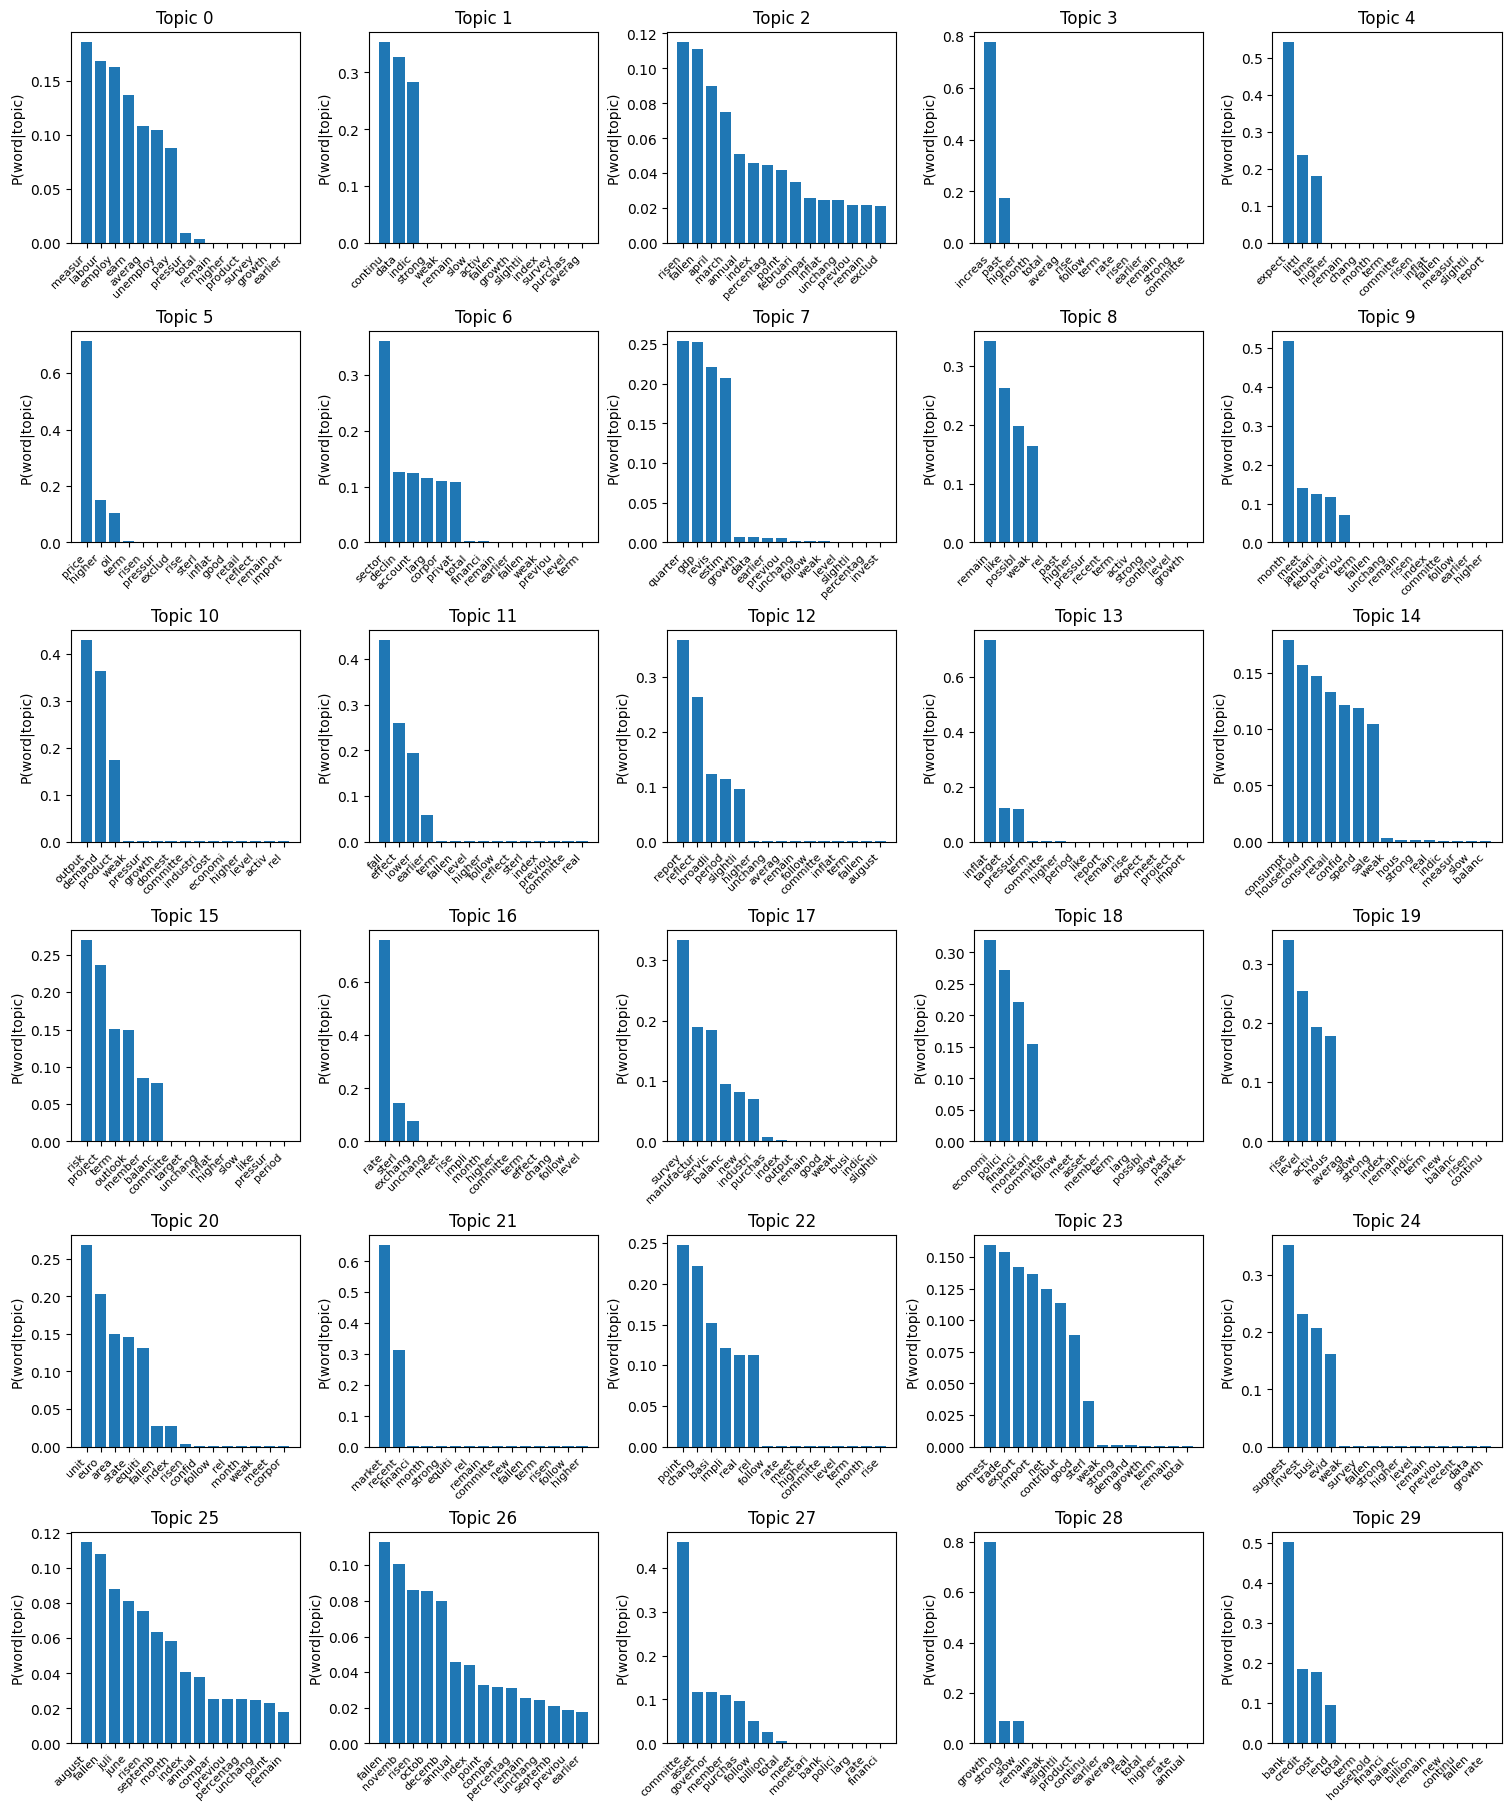

In [25]:
# Plot top 30 topics with top 15 words each
import matplotlib.pyplot as plt
import math

num_to_plot = min(30, len(top_words))
cols = 5
rows = math.ceil(num_to_plot / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), constrained_layout=True)
axes = axes.flatten()
for idx in range(num_to_plot):
    ax = axes[idx]
    words, probs = zip(*top_words[idx][1])
    ax.bar(range(len(words)), probs)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Topic {idx}")
    ax.set_ylabel("P(word|topic)")
for ax in axes[num_to_plot:]:
    ax.axis("off")
plt.show()

### 4.5 Topic Interpretation Notes

**Analysis Results:**
- 根据上方输出的 top words 和可视化结果，以下是我对所有的30个主题的解释：

- Topic 0: likely about labour market and employment measures (劳动力市场与就业指标)
- Topic 1: likely about persistent data indicators (持续数据指标)
- Topic 2: likely about monthly and annual comparisons (月度与同比数据比较)
- Topic 3: likely about growth and past comparisons (增长与历史对比)
- Topic 4: likely about expectations and outlook (预期与展望)
- Topic 5: likely about oil and commodity prices (石油与大宗商品价格)
- Topic 6: likely about sectoral and corporate performance (部门与企业表现)
- Topic 7: likely about GDP and national accounts (GDP与国民核算)
- Topic 8: likely about economic weakness and uncertainty (经济疲软与不确定性)
- Topic 9: likely about monthly meetings and data releases (月度会议与数据发布)
- Topic 10: likely about output and demand (产出与需求)
- Topic 11: likely about declines and their effects (下降及其影响)
- Topic 12: likely about report interpretation (报告解读)
- Topic 13: likely about inflation targeting and pressures (通胀目标与压力)
- Topic 14: likely about consumption and retail (消费与零售)
- Topic 15: likely about risk assessment and projections (风险评估与预测)
- Topic 16: likely about interest rates and exchange rates (利率与汇率)
- Topic 17: likely about business surveys (商业景气调查)
- Topic 18: likely about macroeconomic policy (宏观经济政策)
- Topic 19: likely about economic activity and housing (经济活动与住房)
- Topic 20: likely about international comparisons and equities (国际比较与股市)
- Topic 21: likely about financial market dynamics (金融市场动态)
- Topic 22: likely about basis point changes and implied rates (基点变化与隐含利率)
- Topic 23: likely about trade and net exports (贸易与净出口)
- Topic 24: likely about investment and business confidence (投资与商业信心)
- Topic 25: likely about credit conditions and corporate finance (信贷条件与公司金融) [关键词未提供，基于上下文推断]
- Topic 26: likely about earnings and wage growth (收入与工资增长) [关键词未提供，基于上下文推断]
- Topic 27: likely about MPC meetings and asset purchases (MPC会议与资产购买)
- Topic 28: likely about economic growth (经济增长)
- Topic 29: likely about banking and credit (银行与信贷)

**Detailed interpretation of three topics (1/2/3):**

- **Topic 1 — 持续数据指标**：continu (0.3539), data (0.3275), indic (0.2841), strong (0.0007), weak (0.0006), remain (0.0005), slow (0.0005), activ (0.0005), fallen (0.0004), growth (0.0004), slightli (0.0004), index (0.0004), survey (0.0004), purchas (0.0004), averag (0.0004)。这个主题聚焦于各类经济数据的持续表现和指标解读。高频词“continu”、“data”、“indic”表明这是在讨论一系列数据点所揭示的经济趋势，并搭配“strong/weak”等形容词描述数据反映的强弱状态。出现在综合分析多个数据来源以判断经济走势的段落中。

- **Topic 2 — 月度与同比数据比较**：risen (0.1152), fallen (0.1110), april (0.0902), march (0.0753), annual (0.0509), index (0.0456), percentag (0.0450), point (0.0417), februari (0.0351), compar (0.0257), inflat (0.0249), unchang (0.0248), previou (0.0220), remain (0.0218), exclud (0.0215)。这个主题专门处理月度时间序列数据及其同比、环比变化。关键词包括具体月份（april, march）、变化方向（risen/fallen）、统计术语（annual, percentage, index）以及比较对象（compar, previou）。出现在讨论最新数据发布、物价指数变动或经济增长率变化的上下文中。

- **Topic 3 — 增长与历史对比**：increas (0.7780), past (0.1754), higher (0.0008), month (0.0008), total (0.0008), averag (0.0008), rise (0.0008), follow (0.0007), term (0.0007), rate (0.0007), risen (0.0006), earlier (0.0006), remain (0.0006), strong (0.0005), committe (0.0005)。这个主题高度聚焦于“增长”（increas）以及与过去时期的对比（past, earlier）。尽管权重高度集中于前两个词，但后续词如“higher”、“rise”、“rate”表明这是在评估当前增长相对于历史水平的变化，可能涉及趋势分析和持续性判断。常见于讨论经济增速、物价涨幅或政策效果的回顾性分析中。